In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from typing import Optional, Type, Union
from scipy.interpolate import CubicSpline
from scipy.signal.windows import gaussian, tukey
from scipy.signal import ShortTimeFFT
import time

#few imports
from few.trajectory.inspiral import EMRIInspiral #function to generate trajectories
from few.trajectory.ode.base import ODEBase #superclass for defining modified flux trajectories
from few.trajectory.ode.flux import KerrEccEqFlux #Adiabatic KerrEccEq base trajectory class

from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum
from few.utils.modeselector import ModeSelector
from few.utils.exceptions import TrajectoryOffGridException

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)

##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################

from few.waveform.base import SphericalHarmonicWaveformBase #generic waveform generation class
from few.utils.baseclasses import SphericalHarmonic, KerrEccentricEquatorial, ParallelModuleBase, BackendLike

from few.utils.constants import YRSID_SI

from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )

use_gpu = False #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself.

In [14]:
# define parameters
m1 = 1e6
m2 = 1e1
a = 0.9
e0 = 0.5
Y0 = 1.0
dist = 1.0
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/5.
phiK = np.pi/6.
Phi_phi0 = 0.1
Phi_theta0 = 0.2
Phi_r0 = 0.3
dt = 10.0
T = 1.0
chi2 = 0.5

#initializing trajectories
start = time.time()
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
print(time.time() - start)

evolve_1PA = True
evolve_primary = False
evolve_2PA = True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]

#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
p0 = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, Y0, *add_args])
print('p0: ', p0)

3.9694836139678955
p0:  7.058834620860338


In [15]:
#waveform setup

sum_kwargs=dict(pad_output=True, odd_len=True)

start = time.time()
wave = GenerateEMRIWaveform(SuperKludgeWaveform,sum_kwargs=sum_kwargs, return_list=True)
print(time.time()-start)

41.79809308052063


In [16]:
#compute the actual waveform
waveform = wave(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)

In [17]:
# STFT

Tarr = np.arange(0.0,T*YRSID_SI,dt) #array of time in seconds
N = len(Tarr)

fs = 1/dt

#window
window_scale_in_days = 1.0
window_scale = int((window_scale_in_days * 24 * 60 * 60)/dt) #in #samples = seconds * samples per second
print("window_scale: ", window_scale)

window = gaussian(3 * window_scale, std = window_scale, sym=True) #3sigma Gaussian window

#SFT
SFT = ShortTimeFFT(win=window, hop = window_scale, fs = fs) #1-sigma hop
waveform_SFT = [SFT.stft(waveform[i]) for i in range(len(waveform))]

waveform_SFT[0].shape

window_scale:  8640


(12961, 368)

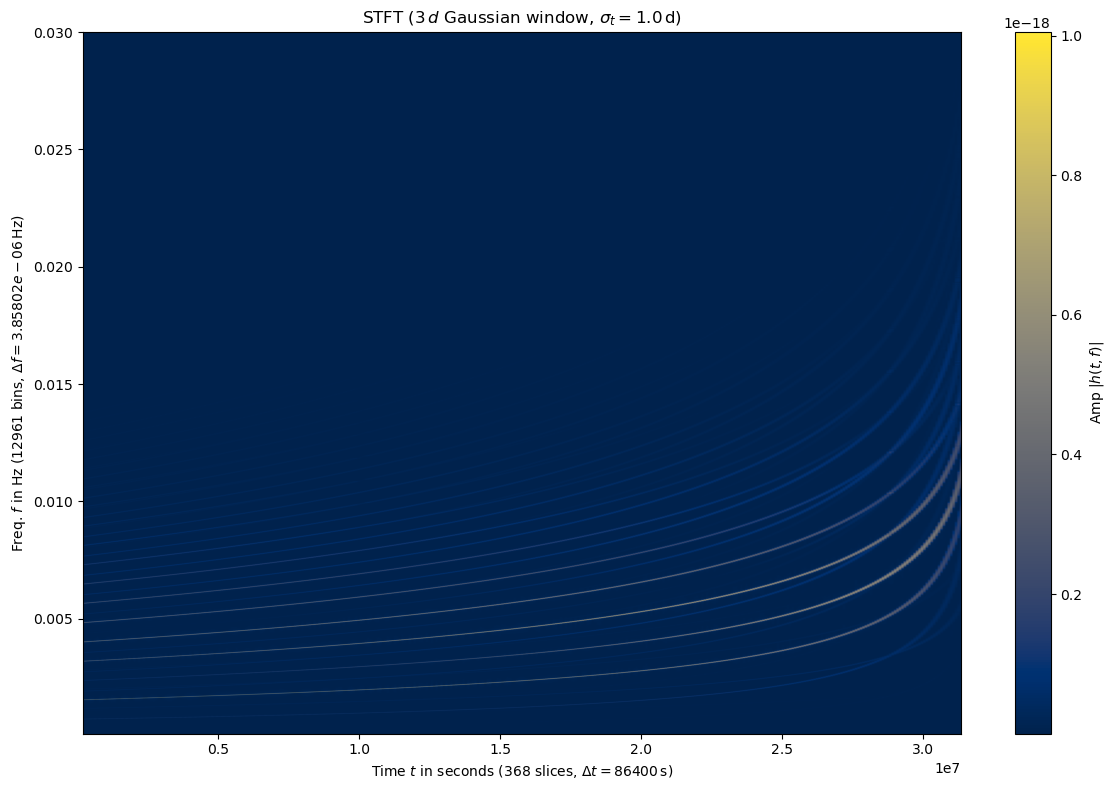

In [19]:
#plotting

fig1, ax1 = plt.subplots(figsize=(12., 8.))
t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
ax1.set_title(rf"STFT ({SFT.m_num*SFT.T/(24* 60 * 60):g}$\,d$ Gaussian window, " +
              rf"$\sigma_t={window_scale*SFT.T/(24 * 60 * 60)}\,$d)")
ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
               rf"$\Delta t = {SFT.delta_t:g}\,$s)",
        ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
               rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
        xlim=(t_lo, t_hi))

im1 = ax1.imshow(np.sqrt(np.sum(abs(np.array(waveform_SFT))**2,axis=0)), origin='lower', aspect='auto',
                 extent=SFT.extent(N), cmap='cividis')

fig1.colorbar(im1, label=r"Amp $|h(t, f)|$")

# Shade areas where window slices stick out to the side:
#for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
#                 (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
#    ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
#for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
#    ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

ax1.set_ylim([1e-4,0.03])
ax1.set_xlim([SFT.lower_border_end[0]*SFT.T,SFT.upper_border_begin(N)[0]*SFT.T])
#ax1.set_yscale('log')
fig1.tight_layout()
plt.savefig("STFTwaveformexample.png",dpi=300,bbox_inches='tight')
plt.show()

In [20]:
waveform_SFT

[array([[ 7.38661530e-22+0.00000000e+00j,  1.11132732e-21+0.00000000e+00j,
          1.27501740e-22+0.00000000e+00j, ...,
          3.03792086e-23+0.00000000e+00j, -4.30972213e-22+0.00000000e+00j,
         -5.74560057e-23+0.00000000e+00j],
        [-4.90229568e-22-4.28926412e-22j,  5.24022424e-22-4.44034727e-25j,
          1.20025010e-22+4.29783636e-22j, ...,
         -4.93958616e-23+7.29414535e-23j, -1.60901040e-22+1.62968876e-22j,
         -1.95476675e-22-2.49533076e-22j],
        [-6.27898274e-24+4.27350271e-22j,  1.11136209e-21+3.69680969e-24j,
         -6.15446155e-22-4.31065459e-22j, ...,
          1.01604811e-22-1.27313621e-22j, -2.64275106e-22+2.79757394e-22j,
          4.41562340e-22-6.75288707e-24j],
        ...,
        [-3.25259757e-23-3.83980400e-23j,  8.37212187e-23-2.54508197e-26j,
         -2.75107193e-23+3.84144841e-23j, ...,
         -1.28407899e-22+1.41177516e-22j, -1.76503275e-22-3.30155678e-22j,
          2.30454375e-22+3.11909726e-23j],
        [-1.18290265e-23+3.